In [1]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from lightning.pytorch import seed_everything
from pathlib import Path
from skimage.io import imread
import spatialdata as spd

import torch
torch.set_float32_matmul_precision("high")

seed_everything(1337)
scvi.settings.seed = 1337

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
[rank: 0] Seed set to 1337
[rank: 0] Seed set to 1337


# Preparing data

In [2]:
zarr_file     = "/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/processing_Zarr/1_C2l_annotations_400"
zdata = spd.read_zarr(zarr_file)

In [3]:
ST_sample = zdata.tables["segmentation_counts"]

## Preprocessing

In [4]:
# ST_sample.obsm["spatial"] = ST_sample.obs[["cx", "cy"]].to_numpy()

In [5]:
ST_sample.layers['counts']

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1766120480 stored elements and shape (2088557, 19059)>

In [6]:
# sc.pp.filter_genes(ST_sample, min_counts=3)
# sc.pp.filter_cells(ST_sample, min_counts=50)

In [7]:
# ST_sample.layers['counts'] = ST_sample.X.copy()
ST_sample.obs["mouse"] = ST_sample.obs["mouse"].astype("category")

In [8]:
# sc.pp.normalize_total(ST_sample, target_sum=1e6)
# sc.pp.log1p(ST_sample)

# Dimensionality Reduction

In [9]:
scvi.model.SCVI.setup_anndata(
    ST_sample,
    layer="counts",
    batch_key="mouse" # after changing
)

model = scvi.model.SCVI(ST_sample)

In [10]:
# COMPUTER
# Autoencoding step to learn embedding representations for each cell
model.train(early_stopping=True, enable_progress_bar=True, accelerator="cuda")

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/4 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=4` reached.


In [11]:
# Save embeddings
ST_sample.obsm['X_scVI'] = model.get_latent_representation(ST_sample).astype(np.float32)

In [12]:
# comptues a graph of neighboring spots/cells based on spatial coordinates and stores it in .osbp['spatial_connectivities"] and "spatial_distance"
# Delaunay... instead of knearest neighbor it identifies the natural geometric neighbors
sq.gr.spatial_neighbors(ST_sample, library_key='mouse', coord_type='generic', delaunay=True, spatial_key='spatial', percentile=99)

# CellCharter's spatial clustering

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


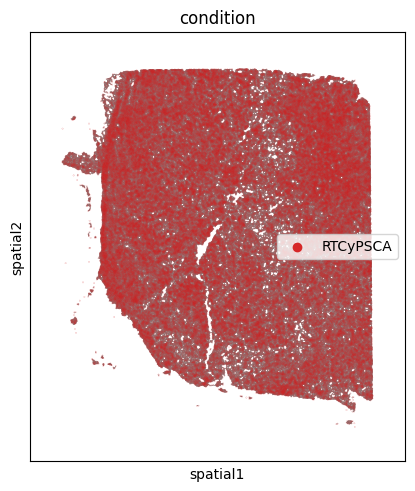

In [13]:
sq.pl.spatial_scatter(
    ST_sample,
    shape=None,
    spatial_key='spatial',
    library_key='mouse',
    library_id=['RTCyPSCA_2_3'],
    img=True,
    img_alpha=1,
    color='condition',
    connectivity_key='spatial_connectivities',
    size=0.01,
    edges_width=0.3,
    legend_loc='right',
    # title=['CyPSCA_1_2']
)


In [14]:
cc.gr.remove_long_links(ST_sample)

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


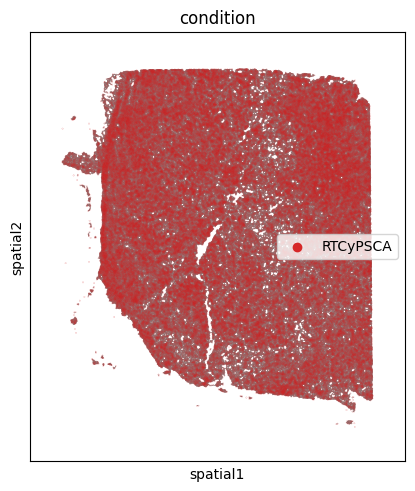

In [15]:
sq.pl.spatial_scatter(
    ST_sample,
    shape=None,
    spatial_key='spatial',
    library_key='mouse',
    library_id=['RTCyPSCA_2_3'],         # or whichever TMA sample contains CyPSCA_1_2
    # crop_coord=crop_coord,
    img=True,
    img_alpha=1,
    color='condition',
    connectivity_key='spatial_connectivities',
    size=0.01,
    edges_width=0.3,
    legend_loc='right',
    # title=['CyPSCA_1_2']
)


# Clustering

## Aggregate Loop

In [16]:
# values 
layers_n =    [1, [0,1], [0,1,2], 2]
# names
layer_names = ["X_cc_1", "X_cc_01", "X_cc_012", "X_cc_2"]

#SS if they match
for layer, name in zip(layers_n, layer_names):
    print(layer, ",", name)

    

1 , X_cc_1
[0, 1] , X_cc_01
[0, 1, 2] , X_cc_012
2 , X_cc_2


In [17]:
for layer, name in zip(layers_n, layer_names):
    print(layer, ",", name)
    cc.gr.aggregate_neighbors(ST_sample, 
                              n_layers=layer, # From list
                              use_rep='X_scVI', 
                              out_key=name, # From list
                              sample_key='mouse'
                             )
    

1 , X_cc_1


  0%|          | 0/32 [00:00<?, ?it/s]

[0, 1] , X_cc_01


  0%|          | 0/32 [00:00<?, ?it/s]

[0, 1, 2] , X_cc_012


  0%|          | 0/32 [00:00<?, ?it/s]

2 , X_cc_2


  0%|          | 0/32 [00:00<?, ?it/s]

## 1 by 1  knn selection

In [18]:
# ST_sample = sc.read_h5ad("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/data/cell_segmentation/concatenated/scvi_all.h5ad")

In [19]:
# cc.gr.aggregate_neighbors(ST_sample, n_layers=[0,1,2], use_rep='X_scVI', out_key='X_cellcharter', sample_key='mouse')

### Fitting and cluster

In [27]:
print("All layers: ", layer_names)
selected_layer = 1 # DONE: 
print("Selected: ", layer_names[selected_layer])

All layers:  ['X_cc_1', 'X_cc_01', 'X_cc_012', 'X_cc_2']
Selected:  X_cc_01


In [28]:

autok = cc.tl.ClusterAutoK(
    n_clusters=(2,10), 
    max_runs=10,
    convergence_tol=0.001
)

In [29]:
autok.fit(ST_sample, use_rep=layer_names[selected_layer])

Iteration 1/10


  0%|          | 0/11 [00:00<?, ?it/s]

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RAN

Iteration 2/10


  0%|          | 0/11 [00:00<?, ?it/s]

...

  0%|          | 0/11 [00:00<?, ?it/s]

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RAN

Iteration 10/10


  0%|          | 0/11 [00:00<?, ?it/s]

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RAN

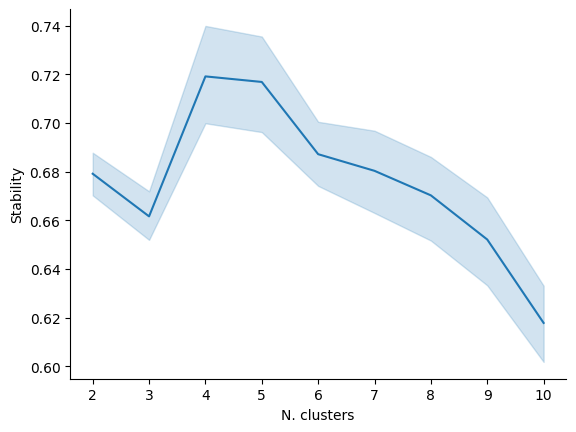

In [30]:
cc.pl.autok_stability(autok)

* X_cc_1 = 6 clusters
* X_cc_01 = 7 clusters
* X_cc_012 = 7 clusters
* X_cc_2 = 7 clusters


In [24]:
# SELECT HERE
k_selection = 4

In [25]:
ST_sample.obs[layer_names[selected_layer]] = autok.predict(ST_sample, use_rep=layer_names[selected_layer], k=k_selection)

print(f"Saving {layer_names[selected_layer]}, with {k_selection} clusters stable")
print("deleting k_selection....")
del k_selection

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Saving X_cc_1, with 4 clusters stable
deleting k_selection....


In [26]:
ST_sample.obs.columns

Index(['sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition',
       'tumor_loc', 'replicate_num', 'c2l_argmax', 'c2l_permissive',
       'c2l_strict', 'c2l_runnerup', 'c2l_consolidated', 'treatment',
       '_scvi_batch', '_scvi_labels', 'X_cc_1'],
      dtype='object')

In [81]:
ST_sample

AnnData object with n_obs × n_vars = 425859 × 19026
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', '_indices', '_scvi_batch', '_scvi_labels', 'batch_core', 'c2l_label_perm', 'c2l_label_strict', 'mt_counts', 'total_RNA_counts', 'treatment', 'n_counts', 'X_cc_1', 'X_cc_01', 'X_cc_012', 'X_cc_2'
    var: 'n_counts'
    uns: 'cell2location_provenance', 'spatialdata_attrs', 'log1p', '_scvi_uuid', '_scvi_manager_uuid', 'spatial_neighbors', 'condition_colors'
    obsm: 'spatial', 'X_scVI', 'X_cc_1', 'X_cc_01', 'X_cc_012', 'X_cc_2'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

# Saving

In [4]:
from pathlib import Path

In [86]:
cellcharter_path = Path("/home/janzules/spatial/CAR-T/data/cellcharter")
cellcharter_path.mkdir(parents=True, exist_ok=True)
out_h5ad = cellcharter_path / "scvi_cellcharter_MultiClustering.h5ad"
ST_sample.write_h5ad(out_h5ad)
print("Wrote:", out_h5ad)

Wrote: /home/janzules/spatial/CAR-T/data/cellcharter/scvi_cellcharter_MultiClustering.h5ad


## Saving Zarr files

In [4]:
import scanpy as sc
import spatialdata as spd

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
# # Reloading 
# adata_file = "/home/janzules/spatial/CAR-T/data/cellcharter/scvi_cellcharter_k6.h5ad"
# adata = sc.read_h5ad(adata_file)

In [92]:
# Loading zarr file
zarr_file = "/home/janzules/spatial/CAR-T/data/cell2location/adata/zarrFiles/CellCharterClusters"
# zdata = spd.read_zarr(zarr_file)


In [88]:
# Replacing adata file
zdata.tables["segmentation_counts"].obs['X_cc_01']

F07839_cellid_000000001-1    6
F07839_cellid_000000002-1    6
F07839_cellid_000000004-1    0
F07839_cellid_000000005-1    0
F07839_cellid_000000006-1    6
                            ..
F08543_cellid_000070488-1    5
F08543_cellid_000070489-1    5
F08543_cellid_000070490-1    5
F08543_cellid_000070491-1    5
F08543_cellid_000070492-1    5
Name: X_cc_01, Length: 425859, dtype: category
Categories (7, object): ['0', '1', '2', '3', '4', '5', '6']

In [85]:
ST_sample

AnnData object with n_obs × n_vars = 425859 × 19026
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', '_indices', '_scvi_batch', '_scvi_labels', 'batch_core', 'c2l_label_perm', 'c2l_label_strict', 'mt_counts', 'total_RNA_counts', 'treatment', 'n_counts', 'X_cc_1', 'X_cc_01', 'X_cc_012', 'X_cc_2'
    var: 'n_counts'
    uns: 'cell2location_provenance', 'spatialdata_attrs', 'log1p', '_scvi_uuid', '_scvi_manager_uuid', 'spatial_neighbors', 'condition_colors'
    obsm: 'spatial', 'X_scVI', 'X_cc_1', 'X_cc_01', 'X_cc_012', 'X_cc_2'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [89]:
# Replacing adata file
zdata.tables["segmentation_counts"] = ST_sample

In [90]:
# Replacing adata file
zdata.tables["segmentation_counts"]

AnnData object with n_obs × n_vars = 425859 × 19026
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', '_indices', '_scvi_batch', '_scvi_labels', 'batch_core', 'c2l_label_perm', 'c2l_label_strict', 'mt_counts', 'total_RNA_counts', 'treatment', 'n_counts', 'X_cc_1', 'X_cc_01', 'X_cc_012', 'X_cc_2'
    var: 'n_counts'
    uns: 'cell2location_provenance', 'spatialdata_attrs', 'log1p', '_scvi_uuid', '_scvi_manager_uuid', 'spatial_neighbors', 'condition_colors'
    obsm: 'spatial', 'X_scVI', 'X_cc_1', 'X_cc_01', 'X_cc_012', 'X_cc_2'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [93]:
zdata.write(zarr_file, overwrite=True)

In [94]:
zarr_file

'/home/janzules/spatial/CAR-T/data/cell2location/adata/zarrFiles/CellCharterClusters'

In [50]:
# sq.pl.spatial_scatter(
#     ST_sample, 
#     color=['cluster_cellcharter'], 
#     library_key='library_id',  
#     size=0.5, 
#     img=None,
#     spatial_key='spatial',
#     palette='Set2',
#     figsize=(5,5),
#     ncols=1,
#     library_id=['F07839'],
# )

In [ ]:
# sq.pl.spatial_scatter(
#     ST_sample, 
#     color=['cluster_cellcharter'], 
#     library_key='mouse',  
#     size=0.5, 
#     img=None,
#     spatial_key='spatial',
#     palette='Set2',
#     figsize=(5,5),
#     ncols=1,
#     library_id=['CyPSCA_1_2'],
# )